# ScriptFormer — Kaggle Notebook (with full diagnostics)
**Before running:** Settings → Accelerator → GPU T4 | Add both datasets in the right panel

Datasets needed:
- `scriptformer-code` — your ScriptFormer project
- `khatt-dataset` — your KHATT data

---
## STEP 1 — GPU check

In [1]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU           :', torch.cuda.get_device_name(0))
    print('VRAM          :', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')
else:
    raise RuntimeError('No GPU found — go to Settings → Accelerator → GPU T4 and restart kernel')

CUDA available: True
GPU           : Tesla T4
VRAM          : 15.6 GB


---
## STEP 2 — Extract project code

In [2]:
import os, shutil

CODE_INPUT = '/kaggle/input/datasets/tahri11/scriptformer'
assert os.path.exists(CODE_INPUT), 'scriptformer-code dataset not found!'

candidates = [d for d in os.listdir(CODE_INPUT) if os.path.isdir(os.path.join(CODE_INPUT, d))]
print('Contents of scriptformer-code:', os.listdir(CODE_INPUT))

PROJECT_DIR = '/kaggle/working/ScriptFormer'
if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

src = os.path.join(CODE_INPUT, candidates[0]) if candidates else CODE_INPUT
shutil.copytree(src, PROJECT_DIR)
os.chdir(PROJECT_DIR)

print('Project dir  :', PROJECT_DIR)
print('Files present:', os.listdir('.'))

Contents of scriptformer-code: ['ScriptFormer-main']
Project dir  : /kaggle/working/ScriptFormer
Files present: ['model', 'configs', 'training', 'inference', 'preprocessing', 'README.md', 'data', 'postprocessing', 'scripts', '__init__.py', 'evaluation', '.gitignore']


---
## STEP 3 — Link KHATT data + verify structure

In [3]:
import os

DATA_INPUT = '/kaggle/input/datasets/tahri11/khatt-dataset'
assert os.path.exists(DATA_INPUT), 'khatt-dataset not found!'

print('KHATT dataset root contents:')
for item in os.listdir(DATA_INPUT):
    print(' -', item)

# train.py expects: data/raw/KHATT/Train.csv, Train_deskewed/, Validation.csv, Validate_deskewed/
RAW_DIR = os.path.join(PROJECT_DIR, 'data', 'raw')
os.makedirs(RAW_DIR, exist_ok=True)

KHATT_LINK = os.path.join(RAW_DIR, 'KHATT')
if os.path.islink(KHATT_LINK) or os.path.exists(KHATT_LINK):
    if os.path.islink(KHATT_LINK): os.remove(KHATT_LINK)
    else: shutil.rmtree(KHATT_LINK)

KHATT_SRC = os.path.join(DATA_INPUT, 'KHATT') if os.path.exists(os.path.join(DATA_INPUT,'KHATT')) else DATA_INPUT
os.symlink(KHATT_SRC, KHATT_LINK)

print('\nLinked KHATT src :', KHATT_SRC)
print('Linked KHATT dest:', KHATT_LINK)

# --- Verify all required files/folders exist ---
required = [
    ('Train.csv',                    'KHATT_LINK/Train.csv'),
    ('Validation.csv',               'KHATT_LINK/Validation.csv'),
    ('Train_deskewed/Train_deskewed','KHATT_LINK/Train_deskewed/Train_deskewed'),
    ('Validate_deskewed/Validate_deskewed','KHATT_LINK/Validate_deskewed/Validate_deskewed'),
]
print('\nChecking expected KHATT structure:')
all_ok = True
for label, rel in required:
    full = os.path.join(KHATT_LINK, label)
    ok = os.path.exists(full)
    print(f'  [{"OK" if ok else "MISSING"}] {full}')
    if not ok: all_ok = False

if all_ok:
    print('\nAll KHATT files found!')
else:
    print('\nSome files are missing — check your KHATT zip structure')
    print('Here is what is actually inside KHATT_LINK:')
    for root, dirs, files in os.walk(KHATT_LINK):
        level = root.replace(KHATT_LINK, '').count(os.sep)
        if level > 2: continue
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        for f in files[:3]:
            print(f'{indent}  {f}')

KHATT dataset root contents:
 - Train_deskewed
 - Validation.csv
 - Validate_deskewed
 - Train.csv

Linked KHATT src : /kaggle/input/datasets/tahri11/khatt-dataset
Linked KHATT dest: /kaggle/working/ScriptFormer/data/raw/KHATT

Checking expected KHATT structure:
  [OK] /kaggle/working/ScriptFormer/data/raw/KHATT/Train.csv
  [OK] /kaggle/working/ScriptFormer/data/raw/KHATT/Validation.csv
  [OK] /kaggle/working/ScriptFormer/data/raw/KHATT/Train_deskewed/Train_deskewed
  [OK] /kaggle/working/ScriptFormer/data/raw/KHATT/Validate_deskewed/Validate_deskewed

All KHATT files found!


---
## STEP 4 — Install dependencies

In [4]:
!pip install -q timm transformers scikit-image pyyaml

---
## STEP 5 — Patch config for GPU + Kaggle paths

In [5]:
import yaml

CONFIG_PATH = 'configs/default.yml'
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

cfg['project']['device'] = 'cuda'
cfg['data']['raw_dir'] = 'data/raw'
cfg['data']['processed_dir'] = 'data/processed'
cfg['training']['checkpoint_dir'] = '/kaggle/working/checkpoints'
cfg['logging']['log_dir'] = '/kaggle/working/logs'

# Uncomment next line if you get GPU out-of-memory errors:
# cfg['training']['batch_size'] = 8

with open(CONFIG_PATH, 'w') as f:
    yaml.dump(cfg, f)

print('Config patched — final values:')
print(f"  device         : {cfg['project']['device']}")
print(f"  raw_dir        : {cfg['data']['raw_dir']}")
print(f"  checkpoint_dir : {cfg['training']['checkpoint_dir']}")
print(f"  batch_size     : {cfg['training']['batch_size']}")
print(f"  epochs         : {cfg['training']['epochs']}")
print(f"  learning_rate  : {cfg['training']['learning_rate']}")
print(f"  image size     : {cfg['data']['image']['height']} x {cfg['data']['image']['width']}")
print(f"  max_seq_length : {cfg['model']['decoder']['max_length']}")

Config patched — final values:
  device         : cuda
  raw_dir        : data/raw
  checkpoint_dir : /kaggle/working/checkpoints
  batch_size     : 16
  epochs         : 50
  learning_rate  : 0.0001
  image size     : 64 x 1024
  max_seq_length : 128


---
## STEP 6 — Diagnostic: data loading + tokenizer + preprocessing

This cell does NOT train yet. It loads a few samples and prints everything so you can catch
problems with labels, images, missing files, or the tokenizer *before* wasting GPU time.

DIAGNOSTIC 1/5 — Dataset parsing
  Train samples : 9497
  Val samples   : 1901

  First 3 train samples:
    path : data/raw/KHATT/Train_deskewed/Train_deskewed/AHTD3A0058_Para2_1.jpg
    text : 'كل أنشاءات التدريس مجهزة تماما .كلها جديدة و متقدمة , فشاشات الكمبيوتر'
    exists: True

    path : data/raw/KHATT/Train_deskewed/Train_deskewed/AHTD3A0058_Para2_2.jpg
    text : 'كلها (بلور مسال) , السبورات —لية يمكن تحويلها ألئ شاشات للعرض .'
    exists: True

    path : data/raw/KHATT/Train_deskewed/Train_deskewed/AHTD3A0083_Para2_1.jpg
    text : 'كنت اشنري الملابس الجينز و الشورتات من علئ حدود بولندا وابيعها'
    exists: True

DIAGNOSTIC 2/5 — Tokenizer
  Vocab size : 64
  PAD id     : 0
  SOS id     : 1
  EOS id     : 2
  Vocab chars: ['<PAD>', '<SOS>', '<EOS>', '<UNK>', ' ', '!', '"', '%', "'", '(', ')', ',', '-', '.', '/', ':', '=', '\\', '_', '؛'] ...

  Round-trip test:
    original : 'كل أنشاءات التدريس مجهزة تماما .كلها جديدة و متقدمة , فشاشات الكمبيوتر'
    encoded  : [1, 45, 46,

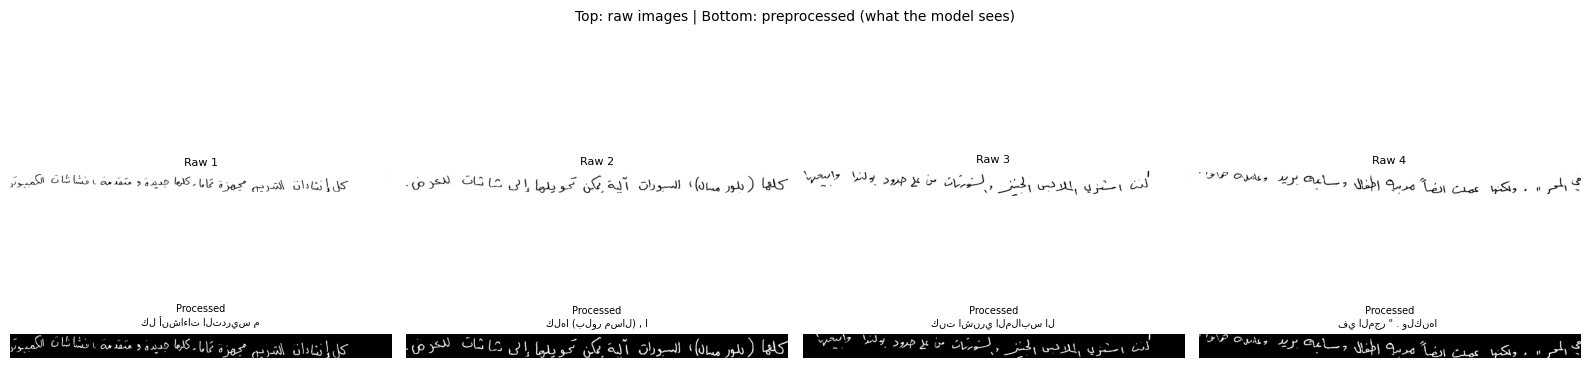

  Saved to /kaggle/working/sample_images.png

DIAGNOSTIC 4/5 — Dataset & DataLoader
  Dataset item 0:
    image tensor shape : torch.Size([1, 64, 1024])  dtype=torch.float32
    token tensor shape : torch.Size([72])  dtype=torch.int64
    text               : 'كل أنشاءات التدريس مجهزة تماما .كلها جديدة و متقدمة , فشاشات الكمبيوتر'
    token ids          : [1, 45, 46, 4, 23, 48, 36, 23, 20, 23, 26, 4, 23, 46, 26, 31, 33, 52, 35, 4, 47, 28, 49, 34, 25, 4, 26, 47, 23, 47, 23, 4, 13, 45, 46, 49, 23, 4, 28, 31, 52, 31, 25, 4, 50, 4, 47, 26, 44, 31, 47, 25, 4, 11, 4, 43, 36, 23, 36, 23, 26, 4, 23, 46, 45, 47, 24, 52, 50, 26, 33, 2]

  First batch:
    images     : torch.Size([16, 1, 64, 1024])  dtype=torch.float32
    token_ids  : torch.Size([16, 128])
    texts[0]   : 'فاىدة الكلمات التالية لهذا النص مشمش دراق غيظ  ناء  بث  نسر.'

DIAGNOSTIC 5/5 — Model forward pass
  Encoder params : 1,436,512
  Decoder params : 6,353,984
  Total params   : 7.8M
  Forward pass OK — logits shape: torch.Size

In [ ]:
import sys, os
sys.path.insert(0, PROJECT_DIR)

import yaml
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from data import parse_khatt_dataset, ArabicCharTokenizer, ArabicOCRDataset, collate_fn
from preprocessing import ManuscriptPreprocessor

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# --- 1. Parse dataset ---
print('=' * 60)
print('DIAGNOSTIC 1/5 — Dataset parsing')
data_root = cfg['data']['raw_dir'] + '/KHATT'
data = parse_khatt_dataset(data_root)
train_samples = data['train']
val_samples   = data['val']
print(f'  Train samples : {len(train_samples)}')
print(f'  Val samples   : {len(val_samples)}')
if not train_samples:
    raise RuntimeError('Train set is empty — check KHATT folder structure in STEP 3')

# Show a few raw samples
print('\n  First 3 train samples:')
for s in train_samples[:3]:
    print(f'    path : {s["image_path"]}')
    print(f'    text : {s["text"]!r}')
    print(f'    exists: {os.path.isfile(s["image_path"])}')
    print()

# --- 2. Tokenizer ---
print('=' * 60)
print('DIAGNOSTIC 2/5 — Tokenizer')
tokenizer = ArabicCharTokenizer()
all_texts = [s['text'] for s in train_samples + val_samples]
tokenizer.build_vocab(all_texts)
print(f'  Vocab size : {tokenizer.vocab_size}')
print(f'  PAD id     : {tokenizer.pad_id}')
print(f'  SOS id     : {tokenizer.sos_id}')
print(f'  EOS id     : {tokenizer.eos_id}')
print(f'  Vocab chars: {list(tokenizer.char_to_id.keys())[:20]} ...')

# Round-trip test
sample_text = train_samples[0]['text']
encoded = tokenizer.encode(sample_text, add_special_tokens=True)
decoded = tokenizer.decode(encoded)
print(f'\n  Round-trip test:')
print(f'    original : {sample_text!r}')
print(f'    encoded  : {encoded}')
print(f'    decoded  : {decoded!r}')
if sample_text != decoded:
    print('  *** WARNING: round-trip mismatch! decoded != original ***')
else:
    print('  Round-trip OK')

# --- 3. Preprocessing ---
print('\n' + '=' * 60)
print('DIAGNOSTIC 3/5 — Image preprocessing')
import cv2
import numpy as np
preprocessor = ManuscriptPreprocessor(cfg['preprocessing'])
img_h = cfg['data']['image']['height']
img_w = cfg['data']['image']['width']

raw = cv2.imread(train_samples[0]['image_path'])
print(f'  Raw image shape  : {raw.shape}')
processed = preprocessor(raw, target_height=img_h, target_width=img_w)
print(f'  Processed shape  : {processed.shape}')
print(f'  Value range      : min={processed.min():.3f}  max={processed.max():.3f}  mean={processed.mean():.3f}')
if processed.max() == 0:
    print('  *** WARNING: processed image is all zeros! binarization may have inverted the image ***')

# Show 4 sample images side by side
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for i in range(4):
    s = train_samples[i]
    raw_i = cv2.imread(s['image_path'])
    proc_i = preprocessor(raw_i, target_height=img_h, target_width=img_w)
    axes[0][i].imshow(cv2.cvtColor(raw_i, cv2.COLOR_BGR2RGB))
    axes[0][i].set_title(f'Raw {i+1}', fontsize=8)
    axes[0][i].axis('off')
    axes[1][i].imshow(proc_i, cmap='gray')
    axes[1][i].set_title(f'Processed\n{s["text"][:20]}', fontsize=7)
    axes[1][i].axis('off')
plt.suptitle('Top: raw images | Bottom: preprocessed (what the model sees)', fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('  Saved to /kaggle/working/sample_images.png')

# --- 4. Dataset + DataLoader ---
print('\n' + '=' * 60)
print('DIAGNOSTIC 4/5 — Dataset & DataLoader')
from torch.utils.data import DataLoader
max_len = cfg['model']['decoder']['max_length']

train_dataset = ArabicOCRDataset(train_samples, tokenizer, preprocessor, img_h, img_w, max_len)
img_t, tok_t, txt_t = train_dataset[0]
print(f'  Dataset item 0:')
print(f'    image tensor shape : {img_t.shape}  dtype={img_t.dtype}')
print(f'    token tensor shape : {tok_t.shape}  dtype={tok_t.dtype}')
print(f'    text               : {txt_t!r}')
print(f'    token ids          : {tok_t.tolist()}')

# Check for UNK tokens
unk_count = (tok_t == tokenizer.char_to_id['<UNK>']).sum().item()
if unk_count > 0:
    print(f'  *** WARNING: {unk_count} UNK tokens in this sample — some chars are not in vocab ***')

batch_size = cfg['training']['batch_size']
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    collate_fn=lambda b: collate_fn(b, pad_id=tokenizer.pad_id), num_workers=0
)
batch = next(iter(train_loader))
print(f'\n  First batch:')
print(f'    images     : {batch["images"].shape}  dtype={batch["images"].dtype}')
print(f'    token_ids  : {batch["token_ids"].shape}')
print(f'    texts[0]   : {batch["texts"][0]!r}')

# --- 5. Model forward pass sanity check ---
print('\n' + '=' * 60)
print('DIAGNOSTIC 5/5 — Model forward pass')
import torch
from model import ScriptFormer

dec_cfg = cfg['model']['decoder']
model = ScriptFormer(
    vocab_size=tokenizer.vocab_size,
    encoder_hidden=dec_cfg['hidden_size'],
    decoder_hidden=dec_cfg['hidden_size'],
    decoder_layers=dec_cfg['num_layers'],
    decoder_heads=dec_cfg['num_heads'],
    decoder_ff=dec_cfg['feedforward_size'],
    max_length=max_len,
    dropout=dec_cfg['dropout'],
    pad_id=tokenizer.pad_id,
    sos_id=tokenizer.sos_id,
    eos_id=tokenizer.eos_id,
    debug_shapes=True,
)
params = model.count_parameters()
print(f'  Encoder params : {params["encoder"]}')
print(f'  Decoder params : {params["decoder"]}')
print(f'  Total params   : {params["total_M"]}')

model = model.to('cuda')
imgs  = batch['images'].to('cuda')
toks  = batch['token_ids'].to('cuda')
with torch.no_grad():
    logits = model(imgs, toks[:, :-1])
print(f'  Forward pass OK — logits shape: {logits.shape}  (expected: [{batch_size}, seq_len, {tokenizer.vocab_size}])')

# Quick generation test on 1 image
with torch.no_grad():
    gen = model.generate(imgs[:1], max_length=max_len)
pred = tokenizer.decode(gen[0].tolist())
print(f'\n  Untrained model prediction on first image (should be gibberish):')
print(f'    predicted : {pred!r}')
print(f'    reference : {batch["texts"][0]!r}')

print('\nAll diagnostics passed!')

---
## STEP 7 — Train

In [ ]:
!python scripts/train.py --config configs/default.yml --debug-shapes

  ScriptFormer Training
  Epochs: 50 | Batch size: 16
  Steps/epoch: 594 | Total steps: 29700
  Warmup: 500 steps | Device: cuda
  Parameters: 7,790,496
  [Step    50] Epoch 1 batch 50/594 | Loss: 3.3659 (avg: 3.8613) | LR: 1.00e-05
  [Step   100] Epoch 1 batch 100/594 | Loss: 3.0766 (avg: 3.5122) | LR: 2.00e-05
  [Step   150] Epoch 1 batch 150/594 | Loss: 2.8609 (avg: 3.3308) | LR: 3.00e-05
  [Step   200] Epoch 1 batch 200/594 | Loss: 2.7747 (avg: 3.2080) | LR: 4.00e-05
  [Step   250] Epoch 1 batch 250/594 | Loss: 2.6886 (avg: 3.1117) | LR: 5.00e-05
  [Step   300] Epoch 1 batch 300/594 | Loss: 2.5965 (avg: 3.0328) | LR: 6.00e-05
  [Step   350] Epoch 1 batch 350/594 | Loss: 2.4537 (avg: 2.9650) | LR: 7.00e-05
  [Step   400] Epoch 1 batch 400/594 | Loss: 2.4813 (avg: 2.8938) | LR: 8.00e-05
  [Step   450] Epoch 1 batch 450/594 | Loss: 2.3521 (avg: 2.8331) | LR: 9.00e-05
  [Step   500] Epoch 1 batch 500/594 | Loss: 2.0976 (avg: 2.7763) | LR: 1.00e-04
  [Step   550] Epoch 1 batch 550/594 |

---
## STEP 8 — Post-training evaluation (CER / WER + sample predictions)

Run this after training finishes to see real predictions vs references.

In [8]:
import sys, os, yaml, torch
sys.path.insert(0, PROJECT_DIR)

from inference.pipeline import OCRPipeline
from evaluation.metrics import compute_metrics, print_evaluation_report
from data import parse_khatt_dataset

CHECKPOINT = '/kaggle/working/checkpoints/best_model.pt'
assert os.path.exists(CHECKPOINT), f'Checkpoint not found: {CHECKPOINT}'

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

pipeline = OCRPipeline.from_checkpoint(CHECKPOINT, config_path=CONFIG_PATH, device='cuda')
print('Model loaded from checkpoint')

# Evaluate on first 100 val samples
data = parse_khatt_dataset(cfg['data']['raw_dir'] + '/KHATT')
val_samples = data['val'][:100]
print(f'Evaluating on {len(val_samples)} val samples...')

predictions, references = [], []
for i, s in enumerate(val_samples):
    pred = pipeline.predict(s['image_path'])
    predictions.append(pred)
    references.append(s['text'])
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{len(val_samples)} done...')

metrics = compute_metrics(predictions, references)
print_evaluation_report(metrics, show_samples=10, predictions=predictions, references=references)

Model loaded from checkpoint
Evaluating on 100 val samples...
  20/100 done...
  40/100 done...
  60/100 done...
  80/100 done...
  100/100 done...
   Evaluation Report
  Samples evaluated:     100
  Character Error Rate (CER):  0.1102  (11.02%)
  Word Error Rate (WER):       0.2313  (23.13%)
  Perfect CER (0% error):    13 / 100  (13.0%)
  Perfect WER (0% error):    16 / 100  (16.0%)

  Sample Predictions (first 10):
  [1] CER: 2.8%  WER: 7.1%
    REF: طفنا وسعينا مع شيخ. كان جاري في الخيمة يتكلم وهو ناىم  بكلمات لا إفهمها
    PRD: طفنا وسعينا مع شيخ. كان جاري في الخيمة يتكلم وهو ناىم بكلمات لا افهمها
  [2] CER: 7.0%  WER: 18.2%
    REF: مثل انقض بغلس له الضابط لزمتك.   سإلت راجح هل بلغ إصحابنا
    PRD: مثل انقض بغلس له الضابط لزمتك. سالت راجح هل بلغ اصحابنا
  [3] CER: 1.4%  WER: 12.5%
    REF: ذهب نوح مظفر ضرغام بصح بة رؤوف بن لؤي رايق ظافر عطعوط وهلال خازن عفيف للحج
    PRD: ذهب نوح مظفر ضرغام بصحبة رؤوف بن لؤي رايق ظافر عطعوط وهلال خازن عفيف للحج
  [4] CER: 13.6%  WER: 25.0%
    RE

---
## STEP 9 — Resume from checkpoint (if session expired)
Re-run steps 2–6 first, then run this cell.

In [9]:
import glob
checkpoints = sorted(glob.glob('/kaggle/working/checkpoints/*.pt'))
if checkpoints:
    latest = checkpoints[-1]
    print('Resuming from:', latest)
    !python scripts/train.py --config configs/default.yml --resume {latest}
else:
    print('No checkpoint found, starting fresh')
    !python scripts/train.py --config configs/default.yml

Resuming from: /kaggle/working/checkpoints/checkpoint_epoch_5.pt
Loading checkpoint from /kaggle/working/checkpoints/checkpoint_epoch_5.pt...
  Resumed from epoch 5, best_val_loss=1.2556
  ScriptFormer Training
  Epochs: 50 | Batch size: 16
  Steps/epoch: 594 | Total steps: 29700
  Warmup: 500 steps | Device: cuda
  Parameters: 7,790,496
  [Step  3000] Epoch 1 batch 30/594 | Loss: 1.3521 (avg: 1.2696) | LR: 9.82e-05
  [Step  3050] Epoch 1 batch 80/594 | Loss: 1.5188 (avg: 1.2887) | LR: 9.81e-05
  [Step  3100] Epoch 1 batch 130/594 | Loss: 1.0502 (avg: 1.2803) | LR: 9.81e-05
  [Step  3150] Epoch 1 batch 180/594 | Loss: 1.2425 (avg: 1.2608) | LR: 9.80e-05
  [Step  3200] Epoch 1 batch 230/594 | Loss: 1.0759 (avg: 1.2578) | LR: 9.79e-05
  [Step  3250] Epoch 1 batch 280/594 | Loss: 0.9865 (avg: 1.2552) | LR: 9.78e-05
  [Step  3300] Epoch 1 batch 330/594 | Loss: 1.5695 (avg: 1.2628) | LR: 9.77e-05
  [Step  3350] Epoch 1 batch 380/594 | Loss: 1.0937 (avg: 1.2501) | LR: 9.77e-05
  [Step  3400]

---
## STEP 10 — Save model to output tab

In [10]:
import shutil, glob, os
best = '/kaggle/working/checkpoints/best_model.pt'
tok  = '/kaggle/working/checkpoints/tokenizer.json'
if os.path.exists(best):
    shutil.copy(best, '/kaggle/working/best_model.pt')
    print('best_model.pt ready to download in Output tab')
if os.path.exists(tok):
    shutil.copy(tok, '/kaggle/working/tokenizer.json')
    print('tokenizer.json ready to download in Output tab')
if not os.path.exists(best):
    print('best_model.pt not found — training may not have finished')
    for f in glob.glob('/kaggle/working/checkpoints/*.pt'):
        print(' available:', f)

best_model.pt ready to download in Output tab
tokenizer.json ready to download in Output tab
